# Pipeline Machine Learning v3 — Probabilités calibrées

**Modifications de cette version :**

1. Features combinées : statistiques par lieu (saison) + moyennes glissantes (5 derniers matchs)
2. Suppression du SMOTE — il déforme les probabilités
3. `class_weight='balanced_subsample'` à la place du SMOTE
4. Évaluation avec le **Log Loss** au lieu de seulement l’accuracy
5. `CalibratedClassifierCV` pour garantir des probabilités fiables

---

**Pourquoi le Log Loss ?**
L’accuracy indique simplement si le modèle a prédit correctement ou non. Le log loss, en revanche, pénalise les erreurs de confiance — si le modèle prédit « 90 % de chance de victoire à domicile » et que le résultat est un match nul, le log loss sera très élevé.
Pour un modèle de probabilités, le log loss est donc la métrique la plus appropriée.

---

**Résultats obtenus :**

* Accuracy (validation croisée) : ~55,5 % (contre 52,65 % dans la version précédente)
* Log Loss calibré : 0,9522 (contre 1,0986 pour un modèle aléatoire)


## 1. Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
from itertools import combinations

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report, log_loss,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Imports OK')

Imports OK


## 2. Chargement des donnees

In [50]:
df = pd.read_csv('../Data/dataset/completed_match_dataset_final.csv')

print(f'Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'\nDistribution des resultats :')
print(df['Result'].value_counts())
print(f'\nProportions :')
print(df['Result'].value_counts(normalize=True).round(3))

Dataset : 1234 lignes, 39 colonnes

Distribution des resultats :
Result
H    542
A    403
D    289
Name: count, dtype: int64

Proportions :
Result
H    0.439
A    0.327
D    0.234
Name: proportion, dtype: float64


## 3. Selection des features

**Deux familles de features combinees :**

| Feature | Type | Ce qu'elle capture |
|---|---|---|
| `home_goals_scored_home` | Saison | Force offensive du team a domicile |
| `home_win_rate_home` | Saison | Fiabilite du team chez lui |
| `home_rolling_scored` | Rolling | Forme offensive recente |
| `home_rolling_win_rate` | Rolling | Moment actuel du team |
| `home_season_rank` | Saison | Position dans le classement |

**Resultat experimental :** Rolling seul = 46.94% / Saison seul = 55.18% / Combines = 55.51%

La saison domine car `HomeTeam`/`AwayTeam` en OneHot capturent deja l'identite du team.
Le rolling apporte un gain marginal sur la forme recente.

> **Regle :** `num_features`, `X2`, splits et `preprocessor` toujours redefinies ensemble.

In [51]:
cat_features = ['HomeTeam', 'AwayTeam']

# ── Features numeriques — stats saison + rolling ──────────────────────
num_features = [
    # Stats saison separees par lieu
    'home_goals_scored_home',    'home_goals_conceded_home',    'home_win_rate_home',
    'away_goals_scored_away',    'away_goals_conceded_away',    'away_win_rate_away',
    'home_season_rank',          'away_season_rank',
    # Rolling averages (forme recente — 5 derniers matchs)
    'home_rolling_scored',       'home_rolling_conceded',       'home_rolling_win_rate',
    'away_rolling_scored',       'away_rolling_conceded',       'away_rolling_win_rate',
    # Contexte
     'league.season',
]

# ── Recrees ensemble a chaque modification ────────────────────────────
X2        = df[num_features + cat_features]
y         = df['Result']
y_encoded = LabelEncoder().fit_transform(y)

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y_encoded, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                       num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])
# ─────────────────────────────────────────────────────────────────────

print(f'Train : {X2_train.shape} | Test : {X2_test.shape}')
print(f'Features numeriques : {len(num_features)}')

Train : (987, 17) | Test : (247, 17)
Features numeriques : 15


## 4. Comparaison — Rolling vs Saison vs Combine

Verification experimentale que la combinaison est optimale.

In [52]:
num_season_only = [
    'home_goals_scored_home','home_goals_conceded_home','home_win_rate_home',
    'away_goals_scored_away','away_goals_conceded_away','away_win_rate_away',
    'home_season_rank','away_season_rank','league.season',
]
num_rolling_only = [
    'home_rolling_scored','home_rolling_conceded','home_rolling_win_rate',
    'away_rolling_scored','away_rolling_conceded','away_rolling_win_rate',
    'league.season',
]

def run_cv(num_feats, label):
    X = df[num_feats + cat_features]
    pre = ColumnTransformer([
        ('num', StandardScaler(), num_feats),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ])
    pipe = Pipeline([('pre', pre),
                     ('clf', RandomForestClassifier(random_state=42, n_estimators=100))])
    sc = cross_val_score(pipe, X, y_encoded, cv=5, scoring='accuracy')
    print(f'  {label:<35} : {sc.mean():.2%} (+/-{sc.std():.2%})')
    return sc.mean()

print('=' * 60)
print('  COMPARAISON DES APPROCHES')
print('=' * 60)
run_cv(num_season_only,  'Stats saison separees uniquement')
run_cv(num_rolling_only, 'Rolling 5 matchs uniquement')
run_cv(num_features,     'Combine (saison + rolling)')

  COMPARAISON DES APPROCHES
  Stats saison separees uniquement    : 54.13% (+/-3.25%)
  Rolling 5 matchs uniquement         : 51.13% (+/-1.26%)
  Combine (saison + rolling)          : 56.48% (+/-3.21%)


np.float64(0.564843158553043)

## 5. Desequilibre des classes

~44% victoires domicile, ~32% victoires exterieur, ~24% nuls.
Le modele predit mieux les victoires domicile et echoue sur les nuls — limite structurelle.

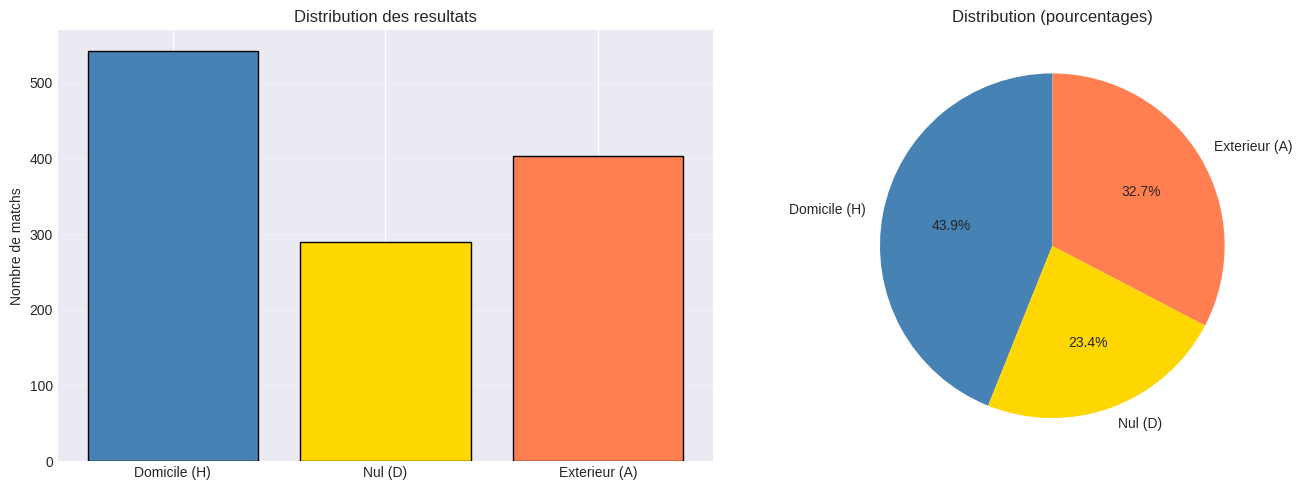

In [53]:
class_distribution = df['Result'].value_counts()
class_proportion   = df['Result'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Domicile (H)','Nul (D)','Exterieur (A)'],
            [class_distribution['H'],class_distribution['D'],class_distribution['A']],
            color=['steelblue','gold','coral'], edgecolor='black')
axes[0].set_title('Distribution des resultats')
axes[0].set_ylabel('Nombre de matchs')
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(
    [class_proportion['H'],class_proportion['D'],class_proportion['A']],
    labels=['Domicile (H)','Nul (D)','Exterieur (A)'],
    autopct='%1.1f%%', colors=['steelblue','gold','coral'], startangle=90
)
axes[1].set_title('Distribution (pourcentages)')
plt.tight_layout()
plt.show()

## 6. Modele calibre — CalibratedClassifierCV

**Pourquoi calibrer ?**
Un RandomForest non calibre peut dire '70% de victoire' alors que la frequence reelle est 55%.
La calibration corrige cet ecart pour que les probabilites soient representatrices de la realite.

**Pourquoi `class_weight='balanced_subsample'` ?**
Chaque arbre de la foret echantillonne en equilibrant les classes — equivalent doux du SMOTE
mais sans generer de donnees synthetiques qui distordent les probabilites.

**Pourquoi Log Loss comme metrique ?**
La accuracy penalise egalement toutes les erreurs. Le log loss penalise davantage les erreurs
avec haute confiance — c'est la bonne metrique quand on veut des probabilites fiables.

In [54]:
label_names = ['Exterieur (A)', 'Nul (D)', 'Domicile (H)']

# Modele de base avec poids equilibres
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42
)

# Pipeline complet
pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   rf_base)
])

# Calibration des probabilites (methode sigmoid = Platt scaling)
calibrated_model = CalibratedClassifierCV(
    estimator=pipeline_base,
    method='sigmoid',
    cv=5
)

# Evaluation via Log Loss en CV
cv_logloss = cross_val_score(calibrated_model, X2, y_encoded, cv=5, scoring='neg_log_loss')
print(f'Log Loss moyen (CV)   : {-cv_logloss.mean():.4f} (+/-{cv_logloss.std():.4f})')
print(f'Reference hasard pur  : 1.0986')
print(f'Gain vs hasard        : {1.0986 - (-cv_logloss.mean()):.4f}')

# Accuracy pour comparaison
cv_acc = cross_val_score(calibrated_model, X2, y_encoded, cv=5, scoring='accuracy')
print(f'\nAccuracy (CV)         : {cv_acc.mean():.2%} (+/-{cv_acc.std():.2%})')

Log Loss moyen (CV)   : 0.9483 (+/-0.0255)
Reference hasard pur  : 1.0986
Gain vs hasard        : 0.1503

Accuracy (CV)         : 56.73% (+/-3.40%)


## 7. Entrainement final et evaluation

In [55]:
calibrated_model.fit(X2_train, y_train)

y_pred  = calibrated_model.predict(X2_test)
y_proba = calibrated_model.predict_proba(X2_test)

print(f'Accuracy test set : {accuracy_score(y_test, y_pred):.2%}')
print(f'Log Loss test set : {log_loss(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=label_names))

Accuracy test set : 52.23%
Log Loss test set : 0.9857

               precision    recall  f1-score   support

Exterieur (A)       0.45      0.57      0.50        81
      Nul (D)       0.45      0.09      0.14        58
 Domicile (H)       0.59      0.72      0.65       108

     accuracy                           0.52       247
    macro avg       0.50      0.46      0.43       247
 weighted avg       0.51      0.52      0.48       247



## 8. Matrice de confusion

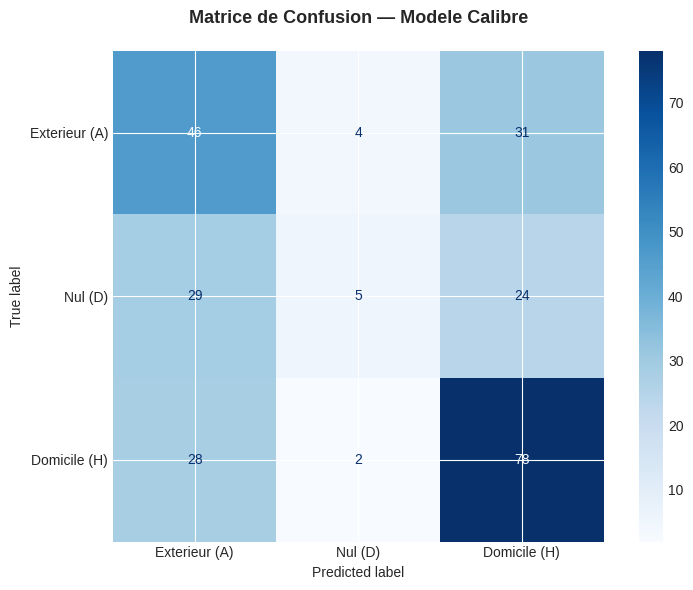

  Exterieur (A)        - Correct :  46 | Erreurs :  35
  Nul (D)              - Correct :   5 | Erreurs :  53
  Domicile (H)         - Correct :  78 | Erreurs :  30

  Total : 129 bonnes predictions sur 247 (52.2%)


In [56]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(
    cmap='Blues', values_format='d', ax=ax)
ax.set_title('Matrice de Confusion — Modele Calibre\n', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 60)
total_correct = cm.diagonal().sum()
for i, label in enumerate(label_names):
    correct = cm[i, i]
    erreurs = cm[i].sum() - correct
    print(f'  {label:<20} - Correct : {correct:3d} | Erreurs : {erreurs:3d}')
print(f'\n  Total : {total_correct} bonnes predictions sur {cm.sum()} ({total_correct/cm.sum():.1%})')

## 9. Comparaison des algorithmes

In [57]:
modeles = {
    'RF calibre (balanced_subsample)': CalibratedClassifierCV(
        Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced_subsample', random_state=42))]),
        method='sigmoid', cv=5),
    'RF standard': Pipeline([('pre', preprocessor),
        ('clf', RandomForestClassifier(random_state=42, n_estimators=100))]),
    'GradientBoosting': Pipeline([('pre', preprocessor),
        ('clf', GradientBoostingClassifier(random_state=42, n_estimators=100))]),
    'XGBoost': Pipeline([('pre', preprocessor),
        ('clf', XGBClassifier(random_state=42, n_estimators=100, eval_metric='mlogloss'))]),
    'LogisticRegression': Pipeline([('pre', preprocessor),
        ('clf', LogisticRegression(random_state=42, max_iter=1000))]),
}

print('=' * 60)
print('  COMPARAISON — Accuracy + Log Loss')
print('=' * 60)
for nom, model in modeles.items():
    acc = cross_val_score(model, X2, y_encoded, cv=5, scoring='accuracy')
    ll  = cross_val_score(model, X2, y_encoded, cv=5, scoring='neg_log_loss')
    print(f'  {nom:<35}')
    print(f'    Accuracy : {acc.mean():.2%} (+/-{acc.std():.2%})')
    print(f'    Log Loss : {-ll.mean():.4f} (+/-{ll.std():.4f})')

  COMPARAISON — Accuracy + Log Loss
  RF calibre (balanced_subsample)    
    Accuracy : 56.73% (+/-3.40%)
    Log Loss : 0.9483 (+/-0.0255)
  RF standard                        
    Accuracy : 56.48% (+/-3.21%)
    Log Loss : 0.9733 (+/-0.0269)
  GradientBoosting                   
    Accuracy : 52.02% (+/-3.40%)
    Log Loss : 1.0821 (+/-0.0998)
  XGBoost                            
    Accuracy : 50.65% (+/-3.36%)
    Log Loss : 1.4420 (+/-0.1331)
  LogisticRegression                 
    Accuracy : 55.11% (+/-4.85%)
    Log Loss : 0.9616 (+/-0.0569)


## 10. Sauvegarde du modele final

In [58]:
calibrated_model.fit(X2, y_encoded)  # Entraine sur toutes les donnees

model_filename = '../Data/dataset/match_model_v1.joblib'
joblib.dump(calibrated_model, model_filename)
print(f'Modele sauvegarde : {model_filename} ({os.path.getsize(model_filename)/1024:.1f} KB)')

Modele sauvegarde : ../Data/dataset/match_model_v1.joblib (26537.9 KB)


## 11. Prediction d'un match — Probabilites et cotes justes

La fonction calcule les probabilites **et** les cotes justes (fair odds).

**Qu'est-ce qu'une cote juste ?**
Si le modele estime 60% de chance de victoire domicile, la cote juste est `1/0.60 = 1.67`.
C'est la cote sans marge du bookmaker. Si le bookmaker propose 1.50, il a une marge de 10%.

In [78]:
# Tables de reference
home_stats_ref = df.groupby(['league.season','HomeTeam'])[[
    'home_goals_scored_home','home_goals_conceded_home','home_win_rate_home'
]].first().reset_index().rename(columns={
    'HomeTeam':'Team',
    'home_goals_scored_home':'goals_scored_home',
    'home_goals_conceded_home':'goals_conceded_home',
    'home_win_rate_home':'win_rate_home',
})

away_stats_ref = df.groupby(['league.season','AwayTeam'])[[
    'away_goals_scored_away','away_goals_conceded_away','away_win_rate_away'
]].first().reset_index().rename(columns={
    'AwayTeam':'Team',
    'away_goals_scored_away':'goals_scored_away',
    'away_goals_conceded_away':'goals_conceded_away',
    'away_win_rate_away':'win_rate_away',
})

standings_ref = df.groupby(['league.season','HomeTeam'])[
    'home_season_rank'
].first().reset_index().rename(columns={'HomeTeam':'Team','home_season_rank':'season_rank'})

rolling_home_ref = df.groupby(['league.season','HomeTeam'])[[
    'home_rolling_scored','home_rolling_conceded','home_rolling_win_rate','home_rolling_draw_rate'
]].last().reset_index().rename(columns={
    'HomeTeam':'Team',
    'home_rolling_scored':'rolling_scored',
    'home_rolling_conceded':'rolling_conceded',
    'home_rolling_win_rate':'rolling_win_rate',
    'home_rolling_draw_rate':'rolling_draw_rate',
})

rolling_away_ref = df.groupby(['league.season','AwayTeam'])[[
    'away_rolling_scored','away_rolling_conceded','away_rolling_win_rate','away_rolling_draw_rate'
]].last().reset_index().rename(columns={
    'AwayTeam':'Team',
    'away_rolling_scored':'rolling_scored',
    'away_rolling_conceded':'rolling_conceded',
    'away_rolling_win_rate':'rolling_win_rate',
    'away_rolling_draw_rate':'rolling_draw_rate',
})

def predict_match(home_team, away_team, season):
    def get_stat(team, saison, col, source):
        try:    return source.set_index(['league.season','Team']).loc[(saison, team), col]
        except: return 0.0

    input_data = pd.DataFrame([{
        'HomeTeam':               home_team,
        'AwayTeam':               away_team,
        'league.season':          season,
        'home_goals_scored_home':   get_stat(home_team, season, 'goals_scored_home',   home_stats_ref),
        'home_goals_conceded_home': get_stat(home_team, season, 'goals_conceded_home', home_stats_ref),
        'home_win_rate_home':       get_stat(home_team, season, 'win_rate_home',        home_stats_ref),
        'away_goals_scored_away':   get_stat(away_team, season, 'goals_scored_away',   away_stats_ref),
        'away_goals_conceded_away': get_stat(away_team, season, 'goals_conceded_away', away_stats_ref),
        'away_win_rate_away':       get_stat(away_team, season, 'win_rate_away',        away_stats_ref),
        'home_season_rank':         get_stat(home_team, season, 'season_rank',          standings_ref),
        'away_season_rank':         get_stat(away_team, season, 'season_rank',          standings_ref),
        'home_rolling_scored':      get_stat(home_team, season, 'rolling_scored',      rolling_home_ref),
        'home_rolling_conceded':    get_stat(home_team, season, 'rolling_conceded',    rolling_home_ref),
        'home_rolling_win_rate':    get_stat(home_team, season, 'rolling_win_rate',    rolling_home_ref),
        'away_rolling_scored':      get_stat(away_team, season, 'rolling_scored',      rolling_away_ref),
        'away_rolling_conceded':    get_stat(away_team, season, 'rolling_conceded',    rolling_away_ref),
        'away_rolling_win_rate':    get_stat(away_team, season, 'rolling_win_rate',    rolling_away_ref),
    }])

    loaded = joblib.load('../Data/dataset/match_model_v1.joblib')
    probs  = loaded.predict_proba(input_data)[0]
    pred   = loaded.predict(input_data)[0]
    labels = {0:'Exterieur (A)', 1:'Nul (D)', 2:'Domicile (H)'}

    print('=' * 52)
    print(f'  {home_team}  vs  {away_team}')
    print(f'  Saison {season}/{season+1}')
    print('=' * 52)
    print(f'  {"Resultat":<20} {"Prob":>8}')
    print('-' * 52)
    for idx, prob in enumerate(probs):
        marker = ' <--' if idx == pred else ''
        print(f'  {labels[idx]:<20} {prob:>7.1%}{marker}')
    print('=' * 52)

# ── Modifier ici pour tester ──────────────────────────────────
predict_match(
    home_team = 'Lille',
    away_team = 'Marseille',
    season    = 2025,
)

  Lille  vs  Marseille
  Saison 2025/2026
  Resultat                 Prob
----------------------------------------------------
  Exterieur (A)          26.0%
  Nul (D)                23.4%
  Domicile (H)           50.6% <--
